#### Baseline Model: Linear Regression — Trip Duration Prediction
# 
**Author:** Abhishek  
**Course:** IST 707 Applied Machine Learning  
**Date:** March 2026  
# 
#### Objective
Build a baseline **Linear Regression** model to predict **trip duration in minutes** 
(`trip_duration_min`) for NYC yellow taxi trips in January 2025 (post-congestion pricing).
#
This serves as the regression baseline that future models (Random Forest, XGBoost, etc.) 
will be compared against.

**Stakeholder Goal:** RMSE < 10 minutes (from stakeholder analysis)


In [39]:
# ## 1. Setup and Libraries

# ============================================
# ### IMPORTING LIBRARIES
# ============================================

import pandas as pd
import numpy as np

# Model
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('default')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [40]:
# ## 2. Load Data and Sample

# ============================================
# ### LOAD ENGINEERED DATA
# ============================================


data = pd.read_parquet(r"C:\Users\hunda\OneDrive\Documents\GitHub\group-project-avengers\data\processed\taxi_engineered.parquet")
print(f"📂 Full dataset: {data.shape[0]:,} trips × {data.shape[1]} columns")

# Sample 500K rows for speed (Linear Regression is fast, but plots render quicker)
SAMPLE_SIZE = 500_000  # Change to len(data) for full dataset
data = data.sample(n=SAMPLE_SIZE, random_state=42)
print(f"✅ Sampled: {data.shape[0]:,} trips")


📂 Full dataset: 2,451,103 trips × 45 columns
✅ Sampled: 500,000 trips


In [41]:
# ## 3. Feature Selection — Avoiding Data Leakage
# 
# ### Key Principle: What does the driver know BEFORE accepting a trip?
# 
# Our stakeholder Maria needs to make a split-second decision when she receives 
# a ride request. At that moment, she knows:
# - **Where:** Pickup zone, dropoff zone (and therefore borough)
# - **When:** Time of day, day of week
# - **Distance:** Approximate trip distance
# - **Passenger count:** How many riders
# 
# She does **NOT** know:
# - Trip duration (that's what we're predicting!)
# - Fare amount, tip, total cost (determined after the trip)
# - Average speed (requires knowing duration)
# - Any surcharges or fee breakdowns (post-trip)
# 
# | Dropped Feature | Reason |
# |---|---|
# | `trip_duration_min` | TARGET — what we're predicting |
# | `has_congestion_fee` | Target for the classification model |
# | `fare_amount`, `tip_amount`, `total_amount`, etc. | Only known after trip ends |
# | `avg_speed_mph` | Computed from duration (leaks target) |
# | `cbd_fee_ratio`, `total_surcharges`, `surcharges_ratio`, `base_fare_ratio` | Post-trip fee breakdowns |
# | `tip_to_total_ratio`, `is_extreme_fare` | Post-trip financial data |

# ============================================
# DEFINE TARGET AND DROP LEAKY/POST-TRIP FEATURES
# ============================================
target = "trip_duration_min"
y = data[target]

drop_cols = [
    # TARGETS
    "trip_duration_min",
    "has_congestion_fee",
    
    # RAW TIMESTAMP (time features already extracted)
    "tpep_pickup_datetime",
    
    # POST-TRIP FINANCIAL DATA
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    
    # LEAKY DERIVED FEATURES
    "avg_speed_mph",           # uses trip_duration_min in calculation
    "tip_to_total_ratio",      # post-trip
    "is_extreme_fare",         # based on fare_amount
    "cbd_fee_ratio",           # based on cbd_congestion_fee
    "total_surcharges",        # sum of post-trip surcharges
    "surcharges_ratio",        # post-trip ratio
    "base_fare_ratio",         # post-trip ratio
    
    # NOT PREDICTIVE FOR DURATION
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
]

existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

print(f"✅ Target: {target}")
print(f"✅ Dropped {len(existing_drops)} columns (leaky/post-trip/irrelevant)")
print(f"✅ Remaining features: {X.shape[1]}")
print(f"\n📋 Features:\n{list(X.columns)}")

✅ Target: trip_duration_min
✅ Dropped 23 columns (leaky/post-trip/irrelevant)
✅ Remaining features: 22

📋 Features:
['passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'is_rush_hour', 'time_of_day', 'pickup_borough', 'dropoff_borough', 'is_same_borough', 'is_airport_pickup', 'is_airport_trip', 'is_single_passenger', 'distance_category', 'is_extreme_distance', 'payment_name', 'ratecode_name', 'hour_x_dayofweek', 'time_slot']


In [42]:
# ## 4. Encode Categorical Features and Train/Test Split

# ============================================
# ENCODE CATEGORICAL FEATURES
# ============================================
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Convert category dtype to string FIRST, then fill NaN
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  ✅ {col}: {len(le.classes_)} unique values → encoded")

# ============================================
# TRAIN/TEST SPLIT (80/20)
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Train: {X_train.shape[0]:,} trips | Test: {X_test.shape[0]:,} trips")

# ============================================
# SCALE FEATURES
# ============================================
from sklearn.preprocessing import StandardScaler

feature_names = X_train.columns.tolist()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"✅ Features scaled with StandardScaler")
print(f"\n📊 Target (trip_duration_min):")
print(f"   Train — mean: {y_train.mean():.2f} min | median: {y_train.median():.2f} min")
print(f"   Test  — mean: {y_test.mean():.2f} min | median: {y_test.median():.2f} min")


Categorical columns: ['time_of_day', 'pickup_borough', 'dropoff_borough', 'distance_category', 'payment_name', 'ratecode_name']

  ✅ time_of_day: 4 unique values → encoded
  ✅ pickup_borough: 7 unique values → encoded
  ✅ dropoff_borough: 7 unique values → encoded
  ✅ distance_category: 3 unique values → encoded
  ✅ payment_name: 4 unique values → encoded
  ✅ ratecode_name: 5 unique values → encoded

✅ Train: 400,000 trips | Test: 100,000 trips
✅ Features scaled with StandardScaler

📊 Target (trip_duration_min):
   Train — mean: 14.07 min | median: 11.17 min
   Test  — mean: 14.04 min | median: 11.13 min


In [43]:
# ## 5. Train Linear Regression Model
# 
# Linear Regression finds the best-fit hyperplane by minimizing the sum of squared residuals.
# It's the simplest regression model and serves as a natural baseline.
# 
# **Formula:** `trip_duration = β₀ + β₁·distance + β₂·hour + β₃·day_of_week + ...`

# %%
# ============================================
# FIT LINEAR REGRESSION
# ============================================
print("="*60)
print("TRAINING LINEAR REGRESSION MODEL")
print("="*60)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"\n✅ Model trained successfully!")
print(f"   Intercept (β₀): {model.intercept_:.4f}")
print(f"   Number of coefficients: {len(model.coef_)}")

TRAINING LINEAR REGRESSION MODEL

✅ Model trained successfully!
   Intercept (β₀): 14.0735
   Number of coefficients: 22


In [44]:
# ## 6. Predictions

# ============================================
# GENERATE PREDICTIONS
# ============================================
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"✅ Predictions generated!")
print(f"   Train predictions — mean: {y_pred_train.mean():.2f} min | std: {y_pred_train.std():.2f}")
print(f"   Test predictions  — mean: {y_pred_test.mean():.2f} min | std: {y_pred_test.std():.2f}")

✅ Predictions generated!
   Train predictions — mean: 14.07 min | std: 9.23
   Test predictions  — mean: 14.03 min | std: 9.22


In [45]:
### 7. Model Evaluation
# 
# We evaluate using three standard regression metrics:
#  - **RMSE (Root Mean Squared Error):** Average prediction error in minutes.  
#    Penalizes large errors more heavily. Our stakeholder goal is RMSE < 10 minutes.
#  - **MAE (Mean Absolute Error):** Average absolute error in minutes.  
#    More interpretable and less sensitive to outliers.
#  - **R² (Coefficient of Determination):** Proportion of variance explained.  
#    1.0 = perfect, 0.0 = no better than predicting the mean.

#  We also compare against a **naive baseline** (always predicting the training mean)
#  to verify the model is actually learning something.


# ============================================
# EVALUATION METRICS
# ============================================
print("="*60)
print("MODEL EVALUATION")
print("="*60)

# --- Training Metrics ---
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

# --- Test Metrics ---
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

# --- Print Results Table ---
print(f"\n{'Metric':<25} {'Train':>10} {'Test':>10}")
print("-" * 47)
print(f"{'RMSE (minutes)':<25} {train_rmse:>10.2f} {test_rmse:>10.2f}")
print(f"{'MAE (minutes)':<25} {train_mae:>10.2f} {test_mae:>10.2f}")
print(f"{'R² Score':<25} {train_r2:>10.4f} {test_r2:>10.4f}")

# --- Naive Baseline Comparison ---
# A model that always predicts the training mean duration
naive_pred = np.full_like(y_test, y_train.mean())
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_mae = mean_absolute_error(y_test, naive_pred)

improvement_pct = ((naive_rmse - test_rmse) / naive_rmse) * 100

print(f"\n{'='*47}")
print(f"📊 NAIVE BASELINE (always predict mean = {y_train.mean():.2f} min):")
print(f"   Naive RMSE: {naive_rmse:.2f} minutes")
print(f"   Naive MAE:  {naive_mae:.2f} minutes")
print(f"   Our model is {improvement_pct:.1f}% better than naive (RMSE)")

# --- Stakeholder Goal Check ---
print(f"\n📊 STAKEHOLDER GOAL: RMSE < 10 minutes")
if test_rmse < 10:
    print(f"   ✅ ACHIEVED — Test RMSE = {test_rmse:.2f} minutes")
else:
    print(f"   ❌ NOT YET — Test RMSE = {test_rmse:.2f} minutes")
    print(f"   Gap: {test_rmse - 10:.2f} minutes above target")
    print(f"   This is a BASELINE — advanced models should improve this.")

# --- Overfitting Check ---
print(f"\n📊 OVERFITTING CHECK:")
rmse_gap = abs(train_rmse - test_rmse)
if rmse_gap < 0.5:
    print(f"   ✅ No overfitting (Train-Test RMSE gap: {rmse_gap:.2f} min)")
elif rmse_gap < 1.0:
    print(f"   ⚠️ Slight gap but acceptable (Train-Test RMSE gap: {rmse_gap:.2f} min)")
else:
    print(f"   ❌ Possible overfitting (Train-Test RMSE gap: {rmse_gap:.2f} min)")


MODEL EVALUATION

Metric                         Train       Test
-----------------------------------------------
RMSE (minutes)                  5.37       5.45
MAE (minutes)                   3.73       3.75
R² Score                      0.7472     0.7386

📊 NAIVE BASELINE (always predict mean = 14.07 min):
   Naive RMSE: 10.66 minutes
   Naive MAE:  7.52 minutes
   Our model is 48.9% better than naive (RMSE)

📊 STAKEHOLDER GOAL: RMSE < 10 minutes
   ✅ ACHIEVED — Test RMSE = 5.45 minutes

📊 OVERFITTING CHECK:
   ✅ No overfitting (Train-Test RMSE gap: 0.09 min)


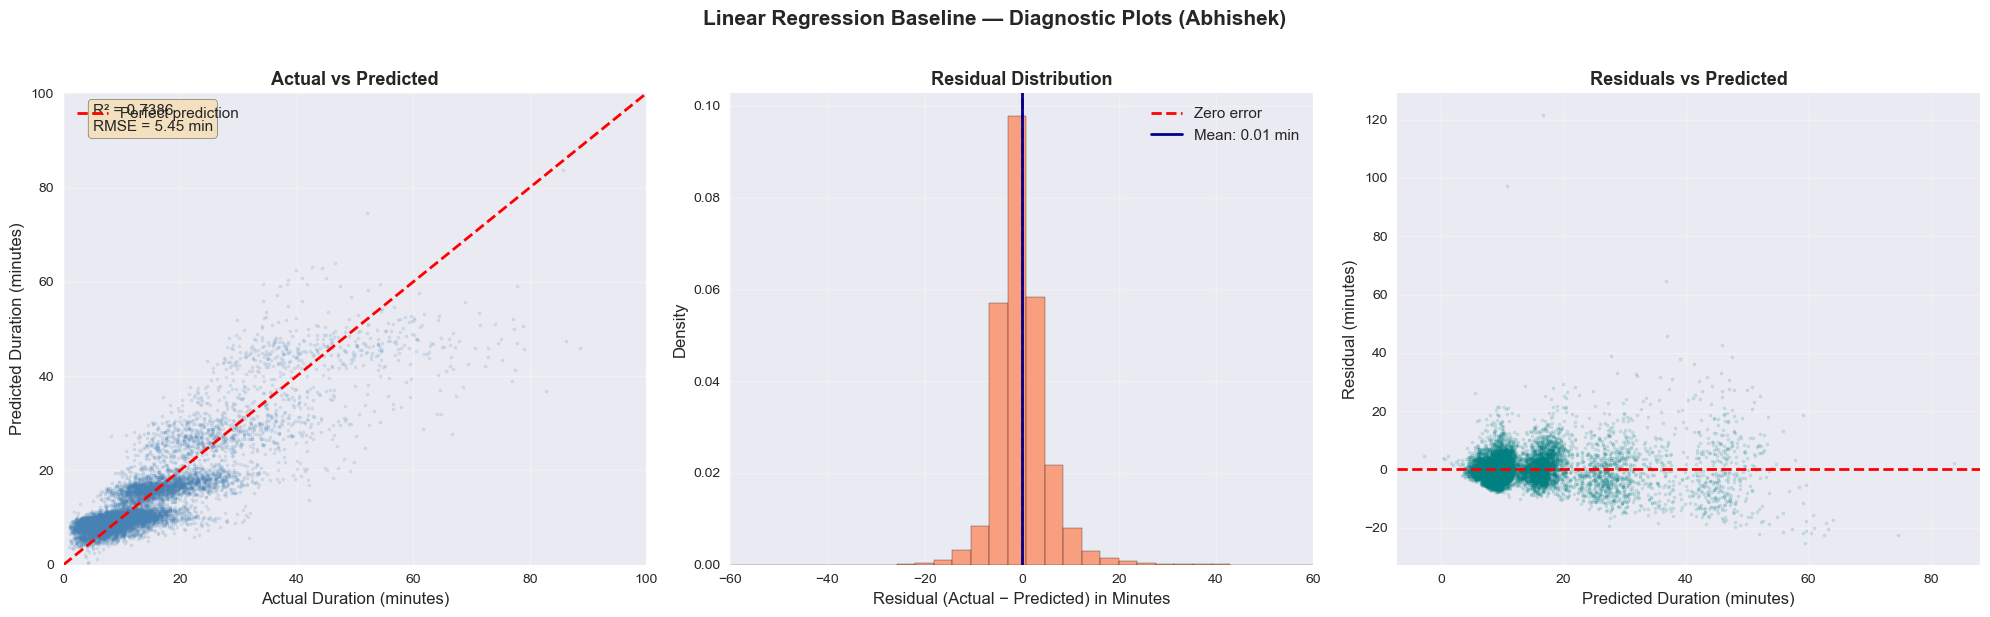

✅ Diagnostic plots generated!


In [46]:
#### 8. Visualizations
# 
# Three key diagnostic plots:
# 1. **Actual vs Predicted** — How close are our predictions to reality?
# 2. **Residual Distribution** — Are errors normally distributed? (LR assumption)
# 3. **Residuals vs Predicted** — Any patterns? (Should be random scatter)

#### ============================================
# DIAGNOSTIC PLOTS
#### ============================================

residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Linear Regression Baseline — Diagnostic Plots (Abhishek)', 
             fontsize=15, fontweight='bold', y=1.02)

# --------------------------------------------------
# PLOT 1: Actual vs Predicted
# --------------------------------------------------
# Sample points for cleaner scatter
n_plot = min(10000, len(y_test))
idx = np.random.RandomState(42).choice(len(y_test), size=n_plot, replace=False)

axes[0].scatter(np.array(y_test)[idx], y_pred_test[idx], 
                alpha=0.15, s=5, color='steelblue')
max_val = max(np.array(y_test).max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Duration (minutes)', fontsize=12)
axes[0].set_ylabel('Predicted Duration (minutes)', fontsize=12)
axes[0].set_title('Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].text(0.05, 0.92, f'R² = {test_r2:.4f}\nRMSE = {test_rmse:.2f} min', 
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --------------------------------------------------
# PLOT 2: Residual Distribution
# --------------------------------------------------
axes[1].hist(residuals, bins=80, color='coral', edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero error')
axes[1].axvline(np.mean(residuals), color='darkblue', linewidth=2, linestyle='-',
                label=f'Mean: {np.mean(residuals):.2f} min')
axes[1].set_xlabel('Residual (Actual − Predicted) in Minutes', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-60, 60)

# --------------------------------------------------
# PLOT 3: Residuals vs Predicted
# --------------------------------------------------
axes[2].scatter(y_pred_test[idx], np.array(residuals)[idx], 
                alpha=0.15, s=5, color='teal')
axes[2].axhline(0, color='red', linewidth=2, linestyle='--')
axes[2].set_xlabel('Predicted Duration (minutes)', fontsize=12)
axes[2].set_ylabel('Residual (minutes)', fontsize=12)
axes[2].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Diagnostic plots generated!")

FEATURE IMPORTANCE (Standardized Coefficients)

Features ranked by importance:

  ↑ trip_distance                   coef =   7.3768
  ↓ distance_category               coef =  -3.2965
  ↓ is_airport_trip                 coef =  -1.4741
  ↓ time_of_day                     coef =  -1.1345
  ↑ hour_x_dayofweek                coef =   1.1221
  ↓ ratecode_name                   coef =  -1.0485
  ↓ is_weekend                      coef =  -1.0089
  ↓ pickup_hour                     coef =  -0.6933
  ↓ RatecodeID                      coef =  -0.5627
  ↓ dropoff_borough                 coef =  -0.2903
  ↓ time_slot                       coef =  -0.2577
  ↓ is_single_passenger             coef =  -0.2030
  ↓ pickup_borough                  coef =  -0.1820
  ↓ pickup_day_of_week              coef =  -0.1743
  ↑ is_rush_hour                    coef =   0.1601
  ↓ is_extreme_distance             coef =  -0.1201
  ↑ is_same_borough                 coef =   0.1135
  ↓ DOLocationID                    

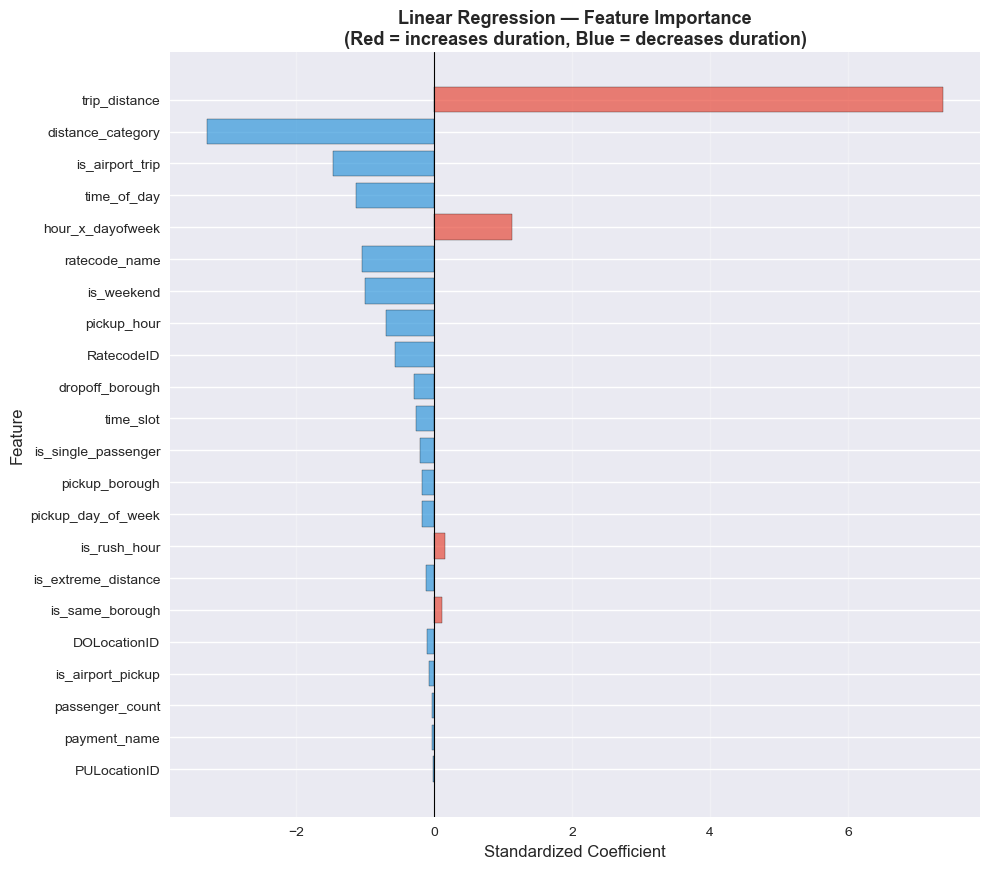

✅ Feature importance analysis complete!


In [47]:
# ---
# ## 9. Feature Importance (Coefficients)
# 
# If the features were scaled with StandardScaler, the coefficient magnitudes 
# are directly comparable. Larger absolute value = stronger influence on predicted duration.
# 
# - **Positive coefficient:** feature increases predicted duration
# - **Negative coefficient:** feature decreases predicted duration

# ============================================
# FEATURE IMPORTANCE
# ============================================
print("="*60)
print("FEATURE IMPORTANCE (Standardized Coefficients)")
print("="*60)

# Build coefficient table
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

# Print ranked features
print(f"\nFeatures ranked by importance:\n")
for _, row in coef_df.iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"  {direction} {row['Feature']:30s}  coef = {row['Coefficient']:>8.4f}")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.4)))

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', alpha=0.7)
ax.set_xlabel('Standardized Coefficient', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Linear Regression — Feature Importance\n(Red = increases duration, Blue = decreases duration)', 
              fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("✅ Feature importance analysis complete!")

In [48]:
#### 10. Summary

#### ============================================
# FINAL SUMMARY
#### ============================================

print("="*70)
print("BASELINE LINEAR REGRESSION — FINAL SUMMARY")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────┐
│  MODEL:  Linear Regression (Baseline)               │
│  TARGET: trip_duration_min                           │
│  FEATURES: {len(feature_names)} (from data prep step)               │
├─────────────────────────────────────────────────────┤
│  RESULTS                                            │
│                                                     │
│  Metric              Train        Test              │
│  ─────────────────────────────────────              │
│  RMSE (minutes)     {train_rmse:>7.2f}      {test_rmse:>7.2f}             │
│  MAE  (minutes)     {train_mae:>7.2f}      {test_mae:>7.2f}             │
│  R² Score           {train_r2:>7.4f}      {test_r2:>7.4f}             │
│                                                     │
│  Naive RMSE:        {naive_rmse:>7.2f} min (predict mean)     │
│  Improvement:       {improvement_pct:>6.1f}% over naive              │
│                                                     │
│  Stakeholder Goal:  RMSE < 10 min                   │
│  Status:            {'ACHIEVED ✅' if test_rmse < 10 else 'NOT YET ❌ — advanced models needed'}       │
└─────────────────────────────────────────────────────┘
""")

# Top 3 features
top3 = coef_df.head(3)
print("🔑 TOP 3 MOST IMPORTANT FEATURES:")
for i, (_, row) in enumerate(top3.iterrows(), 1):
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"   {i}. {row['Feature']} ({direction} duration, coef = {row['Coefficient']:.4f})")

print(f"""
📋 NEXT STEPS:
   1. Compare this baseline (RMSE = {test_rmse:.2f}) against advanced models
   2. Try Random Forest / XGBoost for non-linear relationships
   3. Consider log-transforming the target (right-skewed duration)
   4. Add polynomial or interaction features
""")

print("="*70)
print("✅ Abhishek's baseline complete!")
print("="*70)

BASELINE LINEAR REGRESSION — FINAL SUMMARY

┌─────────────────────────────────────────────────────┐
│  MODEL:  Linear Regression (Baseline)               │
│  TARGET: trip_duration_min                           │
│  FEATURES: 22 (from data prep step)               │
├─────────────────────────────────────────────────────┤
│  RESULTS                                            │
│                                                     │
│  Metric              Train        Test              │
│  ─────────────────────────────────────              │
│  RMSE (minutes)        5.37         5.45             │
│  MAE  (minutes)        3.73         3.75             │
│  R² Score            0.7472       0.7386             │
│                                                     │
│  Naive RMSE:          10.66 min (predict mean)     │
│  Improvement:         48.9% over naive              │
│                                                     │
│  Stakeholder Goal:  RMSE < 10 min                   │
│  